In [2]:
import sys
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
sys.path.append("..")


from load_data import load_all, load_year


df = load_all()               # all four years stacked
df_2021 = load_year("2021")   # for 2021 only
df_2022 = load_year("2022")   # for 2022 only  
df_2023 = load_year("2023")   # for 2023 only
df_2024 = load_year("2024")   # for 2024 only
df_2025 = load_year("2025")   # for 2025 only

In [3]:
print("I need to ask Claude how to combine the 3 versions of 2025 into one combined file for analysis (used for GitHub file size constraints)")

I need to ask Claude how to combine the 3 versions of 2025 into one combined file for analysis (used for GitHub file size constraints)


In [4]:
df_2021.info()
df_2022.info()
df_2023.info()
df_2024.info()
df_2025.info()

<class 'pandas.core.frame.DataFrame'>
Int64Index: 53873 entries, 0 to 53872
Data columns (total 15 columns):
 #   Column                        Non-Null Count  Dtype 
---  ------                        --------------  ----- 
 0   Date received                 53873 non-null  object
 1   Product                       53873 non-null  object
 2   Sub-product                   53873 non-null  object
 3   Issue                         53873 non-null  object
 4   Sub-issue                     53873 non-null  object
 5   Company public response       53873 non-null  object
 6   Company                       53873 non-null  object
 7   State                         53873 non-null  object
 8   ZIP code                      53873 non-null  object
 9   Tags                          53873 non-null  object
 10  Submitted via                 53873 non-null  object
 11  Date sent to company          53873 non-null  object
 12  Company response to consumer  53873 non-null  object
 13  Timely response?

In [5]:
print(f"\n", df_2021['Timely response?'].value_counts())
print(f"\n", df_2022['Timely response?'].value_counts())
print(f"\n", df_2023['Timely response?'].value_counts())
print(f"\n", df_2024['Timely response?'].value_counts())
print(f"\n", df_2025['Timely response?'].value_counts())


 Yes    52183
No      1690
Name: Timely response?, dtype: int64

 Yes    43879
No      1351
Name: Timely response?, dtype: int64

 Yes    48689
No      1155
Name: Timely response?, dtype: int64

 Yes    66855
No      1351
Name: Timely response?, dtype: int64

 Yes    125331
No       3468
Name: Timely response?, dtype: int64


In [6]:
US_STATES = {'AL', 'AK', 'AZ', 'AR', 'CA', 'CO', 'CT', 'DE', 'FL', 'GA', 
             'HI', 'ID', 'IL', 'IN', 'IA', 'KS', 'KY', 'LA', 'ME', 'MD',
             'MA', 'MI', 'MN', 'MS', 'MO', 'MT', 'NE', 'NV', 'NH', 'NJ',
             'NM', 'NY', 'NC', 'ND', 'OH', 'OK', 'OR', 'PA', 'RI', 'SC',
             'SD', 'TN', 'TX', 'UT', 'VT', 'VA', 'WA', 'WV', 'WI', 'WY'}

In [7]:
# Finding the State values outside of the 50 traditional states (territories, DC, military codes, missing, etc.)
non_state_values = df.loc[~df['State'].isin(US_STATES), 'State'].value_counts(dropna=False)
print("Non-state values found in the combined data:\n", non_state_values)

Non-state values found in the combined data:
 DC                                      982
None                                    598
PR                                      529
VI                                       80
AE                                       50
AP                                       44
UNITED STATES MINOR OUTLYING ISLANDS     30
GU                                        7
AA                                        4
MP                                        1
Name: State, dtype: int64


In [8]:
# Standardize to just the 50 traditional US states (drop DC, PR, VI, GU, AA/AE/AP military codes,
# the "UNITED STATES MINOR OUTLYING ISLANDS", missing/None, etc.)
df_states = df[df['State'].isin(US_STATES)].copy()

n_dropped = len(df) - len(df_states)
print(f"Rows before filter: {len(df):,}")
print(f"Rows dropped (non 50-state): {n_dropped:,} ({n_dropped / len(df):.2%})")
print(f"Rows after filter: {len(df_states):,}")
print(f"Unique states remaining: {df_states['State'].nunique()} / 50")

Rows before filter: 345,952
Rows dropped (non 50-state): 2,325 (0.67%)
Rows after filter: 343,627
Unique states remaining: 50 / 50


In [9]:
# This shows the top 10 states by complaint volume, per year, broken down by sub-product ---
# Sub-product colors are FIXED across all 5 year-panels

from matplotlib.colors import LinearSegmentedColormap

CATEGORICAL = ['#2a78d6', '#eb6834', '#1baf7a', '#eda100', '#e87ba4', '#008300', '#4a3aa7']

YEARS = ["2021", "2022", "2023", "2024", "2025"]

GLOBAL_TOP_SUBPRODUCTS = df_states['Sub-product'].value_counts().head(7).index.tolist()
COL_ORDER = GLOBAL_TOP_SUBPRODUCTS + ['Other']
subproduct_color = dict(zip(COL_ORDER, CATEGORICAL + ['#c3c2b7']))  # 'Other' -> neutral gray

year_state_counts = df_states.groupby(['year', 'State']).size().rename('complaint_count')
top10_by_year = (
    year_state_counts
    .groupby('year', group_keys=False)
    .apply(lambda s: s.sort_values(ascending=False).head(10))
    .reset_index()
)

#top10_by_year

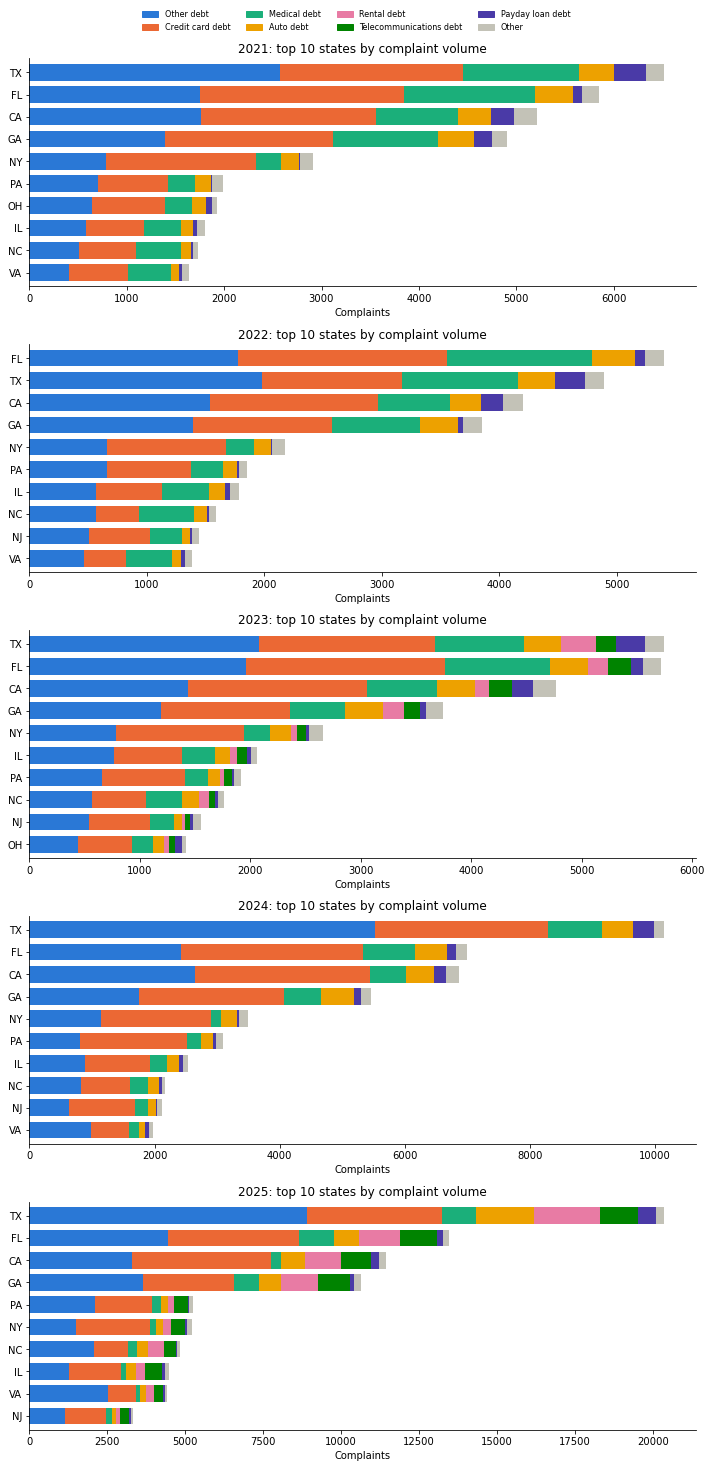

In [10]:
# Bar panels for each year, ordered from top to bottom based on the state with the highest complaint volume
fig, axes = plt.subplots(len(YEARS), 1, figsize=(10, 4 * len(YEARS)))

for ax, year in zip(axes, YEARS):
    top_states = top10_by_year.loc[top10_by_year['year'] == year, 'State'].tolist()
    sub = df_states[(df_states['year'] == year) & (df_states['State'].isin(top_states))].copy()
    sub['Sub-product_grouped'] = np.where(
        sub['Sub-product'].isin(GLOBAL_TOP_SUBPRODUCTS), sub['Sub-product'], 'Other'
    )

    pivot = (
        sub.groupby(['State', 'Sub-product_grouped']).size()
        .unstack(fill_value=0)
        .reindex(index=top_states, columns=COL_ORDER, fill_value=0)
    )

    pivot.plot(
        kind='barh', stacked=True, ax=ax, width=0.75,
        color=[subproduct_color[c] for c in pivot.columns],
        legend=False,
    )
    ax.set_title(f'{year}: top 10 states by complaint volume')
    ax.set_xlabel('Complaints')
    ax.set_ylabel('')
    ax.invert_yaxis()  # highest-volume state on top
    for spine in ('top', 'right'):
        ax.spines[spine].set_visible(False)

# The shared legend for all panels
handles = [plt.Rectangle((0, 0), 1, 1, color=subproduct_color[c]) for c in COL_ORDER]
fig.legend(handles, COL_ORDER, loc='upper center', bbox_to_anchor=(0.5, 1.02),
           ncol=4, frameon=False, fontsize=8)

plt.tight_layout()
plt.show()

In [11]:
# This compares the mix of sub-products vs. response quality, by state  across all years
# The two heatmaps cover the same states x sub-products grid:
#   1) composition: what % of a state's complaints fall in each sub-product
#   2) outcome: the late (non-timely) response rate for that state x sub-product cell
# The purpose is this lets you see, at a glance which states have both a heavy concentration in an
# issue type AND a worse-than-average response rate for that same issue type.

TOP_N_STATES = 15
top_states_overall = df_states['State'].value_counts().head(TOP_N_STATES).index.tolist()

grid = df_states[
    df_states['State'].isin(top_states_overall) & df_states['Sub-product'].isin(GLOBAL_TOP_SUBPRODUCTS)
]

counts = (
    grid.groupby(['State', 'Sub-product']).size()
    .unstack(fill_value=0)
    .reindex(index=top_states_overall, columns=GLOBAL_TOP_SUBPRODUCTS, fill_value=0)
)
composition_pct = counts.div(counts.sum(axis=1), axis=0) * 100

late_rate_pct = (
    grid.groupby(['State', 'Sub-product'])['late'].mean()
    .unstack()
    .reindex(index=top_states_overall, columns=GLOBAL_TOP_SUBPRODUCTS) * 100
)
# The values that come from low response rate complaints can be noisy, so they were omitted from the heatmap.
MIN_CELL_COUNT = 20
late_rate_pct = late_rate_pct.mask(counts < MIN_CELL_COUNT)

composition_pct.round(1)

Sub-product,Other debt,Credit card debt,Medical debt,Auto debt,Rental debt,Telecommunications debt,Payday loan debt
State,,,,,,,
TX,45.1,25.1,10.6,7.2,5.2,3.1,3.7
FL,33.8,35.0,15.0,6.6,4.1,3.8,1.7
CA,34.0,38.5,9.5,6.9,4.0,3.8,3.3
GA,33.7,33.6,13.4,8.2,5.0,4.2,1.9
NY,30.9,49.7,6.9,6.4,1.9,3.5,0.7
PA,36.3,42.1,9.1,5.9,1.6,3.9,1.0
IL,33.2,36.5,12.6,7.4,2.8,5.2,2.2
NC,38.4,28.2,15.8,7.3,5.3,3.7,1.2
VA,45.5,27.7,13.4,5.0,2.8,3.6,2.1


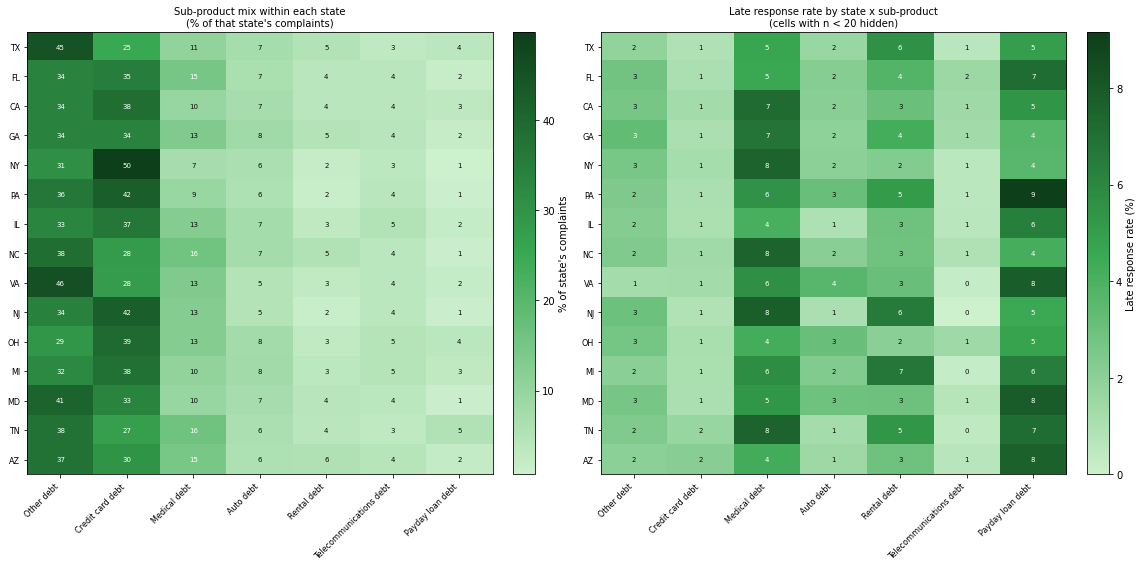

In [18]:
GREEN_SEQ = LinearSegmentedColormap.from_list('green_seq', ['#cdf0cd', '#39a852', '#0d3f1a'])

fig, axes = plt.subplots(1, 2, figsize=(16, 8))

for ax, data, title, cbar_label in [
    (axes[0], composition_pct, 'Sub-product mix within each state\n(% of that state\'s complaints)', '% of state\'s complaints'),
    (axes[1], late_rate_pct, f'Late response rate by state x sub-product\n(cells with n < {MIN_CELL_COUNT} hidden)', 'Late response rate (%)'),
]:
    im = ax.imshow(data.values, cmap=GREEN_SEQ, aspect='auto')
    ax.set_xticks(range(len(data.columns)))
    ax.set_xticklabels(data.columns, rotation=45, ha='right', fontsize=8)
    ax.set_yticks(range(len(data.index)))
    ax.set_yticklabels(data.index, fontsize=8)
    ax.set_title(title, fontsize=10)

    finite_vals = data.values[~np.isnan(data.values)]
    mid = finite_vals.mean() if len(finite_vals) else 0
    for i in range(data.shape[0]):
        for j in range(data.shape[1]):
            val = data.values[i, j]
            if not np.isnan(val):
                ax.text(j, i, f'{val:.0f}', ha='center', va='center', fontsize=7,
                         color='white' if val > mid else '#0b0b0b')

    fig.colorbar(im, ax=ax, label=cbar_label, fraction=0.046, pad=0.04)

plt.tight_layout()
plt.show()


## Important finding from these heatmaps:

### Even though there are many "Other debt" and "Credit card debt" consumers complaints, the CFPB tends to have acceptable response rates for these two sub-products; however, the rarer sub-products like "Medical debt" and "Payday loan debt" have worse response rates.
### **The suggestion**: The CFPB should consider allocating more resources to improve response rates for these rarer sub-products, as they may represent more complex or urgent consumer issues that require timely attention. 

## Standardizing complaint volume by population

The raw top-10-by-state chart above mostly just re-traces state population (Texas, Florida,
California lead because they have the most people, not necessarily the worst service). To make
the "playing field" level, we normalize complaint counts by each state's population, using
2023 U.S. Census Bureau state population estimates. This lets us compare complaint *rates*
rather than raw counts, and separate "big state, proportionally normal" from "disproportionately
generating complaints."

We also build the late-response **disparity ratio**: each state's late-response rate divided by
the national late-response rate for that year. A ratio of 1.5 means a state's consumers are 50%
more likely to get a late response than the national average that year -- the kind of standardized,
benchmarked number that supports both the "under-resourced state" business case and the fair-lending
regulatory angle.

In [13]:
# 2023 U.S. Census Bureau state population estimates (approximate; source: census.gov vintage 2023)
STATE_POPULATION = {
    'AL': 5_108_468, 'AK': 733_406, 'AZ': 7_431_344, 'AR': 3_067_732, 'CA': 38_965_193,
    'CO': 5_877_610, 'CT': 3_617_176, 'DE': 1_031_890, 'FL': 22_610_726, 'GA': 11_029_227,
    'HI': 1_435_138, 'ID': 1_964_726, 'IL': 12_549_689, 'IN': 6_862_199, 'IA': 3_207_004,
    'KS': 2_940_546, 'KY': 4_526_154, 'LA': 4_573_749, 'ME': 1_395_722, 'MD': 6_180_253,
    'MA': 7_001_399, 'MI': 10_037_261, 'MN': 5_742_225, 'MS': 2_939_690, 'MO': 6_196_156,
    'MT': 1_132_812, 'NE': 1_978_379, 'NV': 3_194_176, 'NH': 1_402_054, 'NJ': 9_290_841,
    'NM': 2_114_371, 'NY': 19_571_216, 'NC': 10_835_491, 'ND': 783_926, 'OH': 11_785_935,
    'OK': 4_053_824, 'OR': 4_233_358, 'PA': 12_961_683, 'RI': 1_095_610, 'SC': 5_373_555,
    'SD': 919_318, 'TN': 7_126_489, 'TX': 30_503_301, 'UT': 3_417_734, 'VT': 647_464,
    'VA': 8_715_698, 'WA': 7_812_880, 'WV': 1_770_071, 'WI': 5_910_955, 'WY': 584_057,
}
assert set(STATE_POPULATION) == US_STATES, "population table doesn't match US_STATES"

state_pop = pd.Series(STATE_POPULATION, name='population')

# Complaints per 100k residents, overall (all years pooled)
complaints_per_state = df_states.groupby('State').size().rename('complaint_count')
complaints_per_100k = (
    (complaints_per_state / state_pop * 100_000)
    .rename('complaints_per_100k')
    .sort_values(ascending=False)
)

# Complaints per 100k residents, grouped by the year 
complaints_per_state_year = (
    df_states.groupby(['year', 'State']).size().rename('complaint_count').reset_index()
)
complaints_per_state_year['population'] = complaints_per_state_year['State'].map(state_pop)
complaints_per_state_year['complaints_per_100k'] = (
    complaints_per_state_year['complaint_count'] / complaints_per_state_year['population'] * 100_000
)

print(complaints_per_100k.round(2))
complaints_per_state_year

GA    259.37
DE    174.63
FL    165.56
NV    156.75
TX    156.24
LA    137.90
MD    132.50
SC    128.07
VA    123.99
AL    123.66
NC    111.62
MS    109.81
PA    108.73
TN    107.51
NJ    106.75
IL    100.78
AZ     92.88
RI     86.89
MI     84.21
NY     84.01
CA     83.37
OH     80.92
WV     77.96
CT     76.99
AR     74.97
MA     73.61
MO     69.33
IN     67.27
OK     66.73
CO     58.24
ND     56.64
NM     53.49
UT     53.46
KY     49.76
KS     48.87
WY     48.80
WI     46.96
WA     46.14
OR     44.57
MN     41.27
ID     41.02
IA     40.32
NE     39.98
AK     39.13
NH     38.37
HI     38.32
SD     34.05
ME     32.60
MT     32.04
VT     20.85
Name: complaints_per_100k, dtype: float64


,year,State,complaint_count,population,complaints_per_100k
0,2021,AK,33,733406,4.499554
1,2021,AL,879,5108468,17.206724
2,2021,AR,336,3067732,10.952717
3,2021,AZ,1135,7431344,15.273146
4,2021,CA,5211,38965193,13.373474
...,...,...,...,...,...
245,2025,VT,40,647464,6.177950
246,2025,WA,1305,7812880,16.703188
247,2025,WI,945,5910955,15.987264
248,2025,WV,817,1770071,46.156341


In [14]:
# Late-response disparity ratio: each state's late-rate that year, divided by the
# national late-rate that same year. 1.0 = right at the national average;
# > 1.0 = worse than the national average that year; < 1.0 = better.
national_late_rate_by_year = df_states.groupby('year')['late'].mean()

late_rate_by_state_year = (
    df_states.groupby(['year', 'State'])['late']
    .agg(late_rate='mean', n='size')
    .reset_index()
)
late_rate_by_state_year['national_late_rate'] = late_rate_by_state_year['year'].map(national_late_rate_by_year)
late_rate_by_state_year['disparity_ratio'] = (
    late_rate_by_state_year['late_rate'] / late_rate_by_state_year['national_late_rate']
)

# Small-sample cells are noisy -- flag rather than silently trust them
MIN_N = 20
late_rate_by_state_year['low_sample'] = late_rate_by_state_year['n'] < MIN_N

late_rate_by_state_year.sort_values(['year', 'disparity_ratio'], ascending=[True, False]).head(15)

,year,State,late_rate,n,national_late_rate,disparity_ratio,low_sample
45,2021,VT,0.160000,25,0.031319,5.108708,False
20,2021,ME,0.135135,74,0.031319,4.314787,False
36,2021,OR,0.066914,269,0.031319,2.136542,False
10,2021,HI,0.061538,65,0.031319,1.964888,False
25,2021,MT,0.060000,50,0.031319,1.915766,False
46,2021,WA,0.058528,598,0.031319,1.868779,False
11,2021,IA,0.053922,204,0.031319,1.721685,False
27,2021,ND,0.051282,39,0.031319,1.637406,False
32,2021,NV,0.048813,758,0.031319,1.558560,False
5,2021,CO,0.042254,568,0.031319,1.349131,False


## Heatmap of late-response disparity ratio, by state x year. 1.0 = national average; > 1.0 = worse than national average; < 1.0 = better than national average.

In [17]:
# --- Trend view: state x year, colored by disparity_ratio ---
# Rows ordered by each state's average disparity (worst offenders on top).
# As you go left-to-right across a row you'll see if that state's standing is climbing, falling, or consistent.
disparity_pivot = late_rate_by_state_year.pivot(index='State', columns='year', values='disparity_ratio')
low_sample_pivot = late_rate_by_state_year.pivot(index='State', columns='year', values='low_sample')

state_order = disparity_pivot.mean(axis=1).sort_values(ascending=False).index
disparity_pivot = disparity_pivot.reindex(index=state_order, columns=YEARS)
low_sample_pivot = low_sample_pivot.reindex(index=state_order, columns=YEARS)

disparity_pivot.round(2)

year,2021,2022,2023,2024,2025
State,,,,,
ME,4.31,4.61,6.33,5.82,4.54
MT,1.92,0.66,1.19,5.94,1.79
VT,5.11,0.00,2.47,0.00,1.86
ID,1.25,1.40,1.73,1.46,2.68
WA,1.87,1.70,1.18,1.72,1.57
WV,1.26,2.32,3.33,0.56,0.37
NM,0.99,1.27,1.78,1.42,1.52
KS,0.93,1.54,1.97,1.16,1.26
HI,1.96,2.05,0.34,1.04,1.45


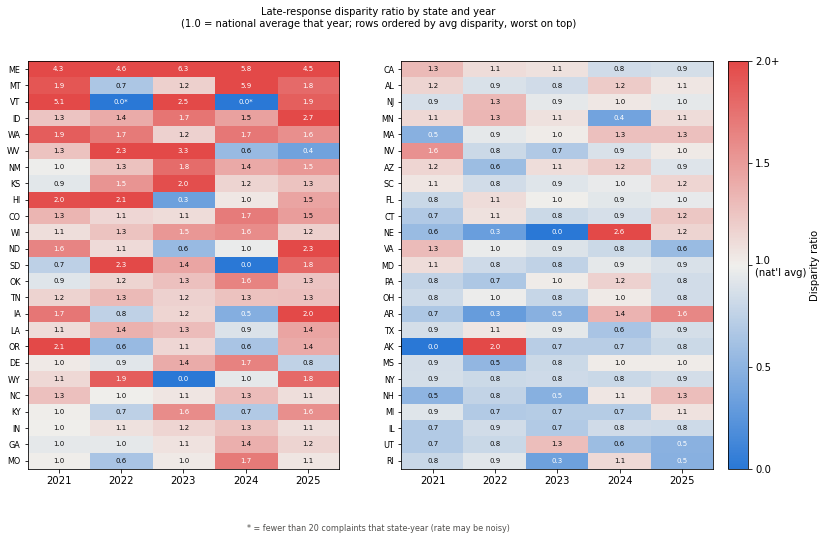

In [19]:
from matplotlib.colors import TwoSlopeNorm

DIVERGING = LinearSegmentedColormap.from_list('blue_red_diverging', ['#2a78d6', '#f0efec', '#e34948'])
norm = TwoSlopeNorm(vmin=0.0, vcenter=1.0, vmax=2.0)

n_states = len(disparity_pivot.index)
split = (n_states + 1) // 2  # top half gets the extra row if odd

halves = [
    (disparity_pivot.iloc[:split], low_sample_pivot.iloc[:split]),
    (disparity_pivot.iloc[split:], low_sample_pivot.iloc[split:]),
]

fig, axes = plt.subplots(1, 2, figsize=(13, 7.5))

for ax, (pivot_half, low_sample_half) in zip(axes, halves):
    im = ax.imshow(pivot_half.values, cmap=DIVERGING, norm=norm, aspect='auto')

    ax.set_xticks(range(len(YEARS)))
    ax.set_xticklabels(YEARS)
    ax.set_yticks(range(len(pivot_half.index)))
    ax.set_yticklabels(pivot_half.index, fontsize=8)

    for i in range(pivot_half.shape[0]):
        for j in range(pivot_half.shape[1]):
            val = pivot_half.values[i, j]
            if np.isnan(val):
                continue
            label = f'{val:.1f}' + ('*' if low_sample_half.values[i, j] else '')
            text_color = 'white' if abs(val - 1.0) > 0.5 else '#0b0b0b'
            ax.text(j, i, label, ha='center', va='center', fontsize=7, color=text_color)

fig.suptitle(
    'Late-response disparity ratio by state and year\n'
    '(1.0 = national average that year; rows ordered by avg disparity, worst on top)',
    fontsize=10,
)

cbar = fig.colorbar(im, ax=axes, fraction=0.035, pad=0.02)
cbar.set_ticks([0.0, 0.5, 1.0, 1.5, 2.0])
cbar.set_ticklabels(['0.0', '0.5', '1.0\n(nat\'l avg)', '1.5', '2.0+'])
cbar.set_label('Disparity ratio')

fig.text(0.5, 0.01, '* = fewer than 20 complaints that state-year (rate may be noisy)',
          ha='center', fontsize=8, color='#52514e')

plt.show()
